# Diabetes Prediction using Naive Bayes and SVM


This project is part of the coursework for **Data Mining** (Spring 2016) under **Prof. Ramadoss**.

It demonstrates the application of Naive Bayes and Support Vector Machines (SVM) for predicting the onset of diabetes based on diagnostic measurements.

## Project Overview
- **Dataset:** Pima Indians Diabetes Dataset
- **Models Used:** Gaussian Naive Bayes, SVM (RBF Kernel), SVM (Linear Kernel)
- **Key Steps:** Data Loading, Preprocessing (Handling Missing Values, Scaling), Model Training, Evaluation, Visualization.

# 1. Setup and Data Loading

## 1.1 Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries imported.")

Libraries imported.


# 1.2 Load dataset


In [ ]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
try:
    data = pd.read_csv(url)
    print("Dataset loaded successfully from URL.")
    print("Shape:", data.shape)
    print(data.head())
except Exception as e:
    print(f"Error loading dataset from URL: {e}")

Dataset loaded successfully from URL.
Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# 2. Preprocessing

In [ ]:
print("\n--- Preprocessing ---")

# Identify columns where 0 likely means missing data
zero_value_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN in these columns
data[zero_value_columns] = data[zero_value_columns].replace(0, np.nan)
print(f"Replaced 0s with NaN in columns: {zero_value_columns}")

# Impute NaN with column medians
print("Imputing NaN values with medians...")
for col in zero_value_columns:
    median_val = data[col].median()
    data[col].fillna(median_val, inplace=True)

# Define features (X) and target (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']
print("Features (X) and Target (y) defined.")


--- Preprocessing ---
Replaced 0s with NaN in columns: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
Imputing NaN values with medians...
Features (X) and Target (y) defined.


# 3. Data Splitting

In [ ]:
print("\n--- Splitting Data ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train/Test split: {X_train.shape[0]}/{X_test.shape[0]} samples.")


--- Splitting Data ---
Train/Test split: 614/154 samples.


# 4. Feature Scaling

In [ ]:
print("\n--- Feature Scaling ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled (StandardScaler).")


--- Feature Scaling ---
Features scaled (StandardScaler).


# 5. Model Training

In [ ]:
print("\n--- Model Training ---")

print("Training Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("Training SVM (RBF Kernel)...")
svm_rbf_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf_model.fit(X_train_scaled, y_train)

print("Training SVM (Linear Kernel)...")
svm_linear_model = SVC(kernel='linear', random_state=42)
svm_linear_model.fit(X_train_scaled, y_train)
print("Models trained.")


--- Model Training ---
Training Naive Bayes...
Training SVM (RBF Kernel)...
Training SVM (Linear Kernel)...
Models trained.


# 6. Model Evaluation


--- Model Evaluation ---

--- Naive Bayes ---
Accuracy: 0.7013
Confusion Matrix:
[[74 26]
 [20 34]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



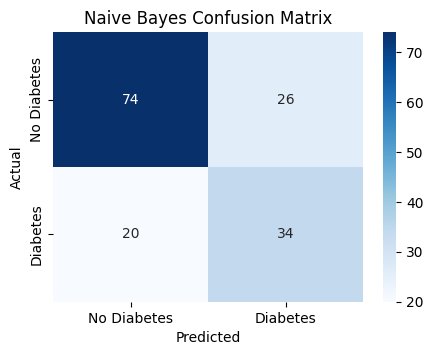


--- SVM (RBF) ---
Accuracy: 0.7403
Confusion Matrix:
[[84 16]
 [24 30]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



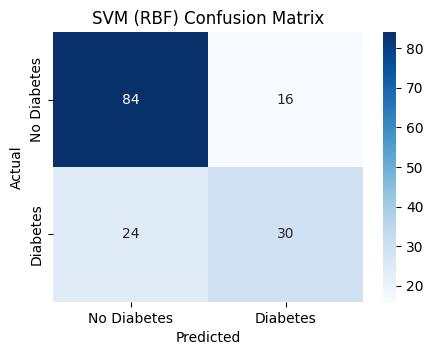


--- SVM (Linear) ---
Accuracy: 0.7013
Confusion Matrix:
[[82 18]
 [28 26]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



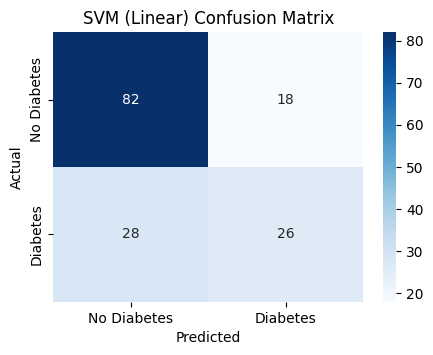

In [ ]:
print("\n--- Model Evaluation ---")

y_pred_nb = nb_model.predict(X_test_scaled)
y_pred_svm_rbf = svm_rbf_model.predict(X_test_scaled)
y_pred_svm_linear = svm_linear_model.predict(X_test_scaled)

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred)
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Classification Report:\n{cr}")

    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_svm_rbf, "SVM (RBF)")
evaluate_model(y_test, y_pred_svm_linear, "SVM (Linear)")

# 7. Visualization

Plotting Feature Importance (Linear SVM)...


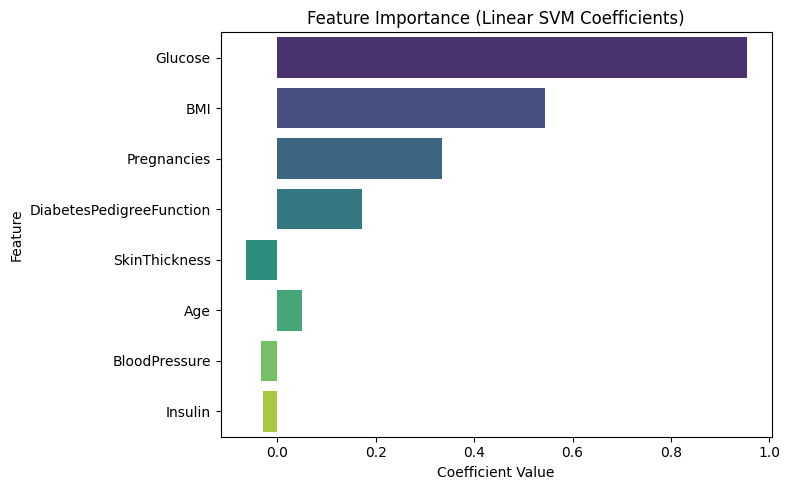


Linear SVM Coefficients:
                     Feature  Importance
1                   Glucose    0.953874
5                       BMI    0.544709
0               Pregnancies    0.334302
6  DiabetesPedigreeFunction    0.172370
3             SkinThickness   -0.064677
7                       Age    0.049754
2             BloodPressure   -0.032422
4                   Insulin   -0.029915


In [ ]:
print("Plotting Feature Importance (Linear SVM)...")
coefficients = svm_linear_model.coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
importance_df = importance_df.sort_values(by='Importance', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance (Linear SVM Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
print("\nLinear SVM Coefficients:\n", importance_df)

Plotting ROC Curves...


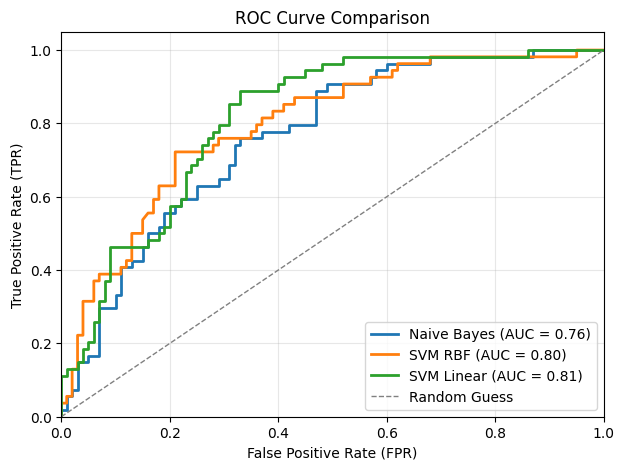

In [ ]:
print("Plotting ROC Curves...")
plt.figure(figsize=(7, 5)) # Adjusted size

fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_model.predict_proba(X_test_scaled)[:, 1])
roc_auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')

fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_test, svm_rbf_model.predict_proba(X_test_scaled)[:, 1])
roc_auc_svm_rbf = auc(fpr_svm_rbf, tpr_svm_rbf)
plt.plot(fpr_svm_rbf, tpr_svm_rbf, lw=2, label=f'SVM RBF (AUC = {roc_auc_svm_rbf:.2f})')

y_score_svm_linear = svm_linear_model.decision_function(X_test_scaled)
fpr_svm_linear, tpr_svm_linear, _ = roc_curve(y_test, y_score_svm_linear)
roc_auc_svm_linear = auc(fpr_svm_linear, tpr_svm_linear)
plt.plot(fpr_svm_linear, tpr_svm_linear, lw=2, label=f'SVM Linear (AUC = {roc_auc_svm_linear:.2f})')

plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 8. Accuracy

In [ ]:
print("Accuracy Summary:")
print(f"- Naive Bayes: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"- SVM (RBF):   {accuracy_score(y_test, y_pred_svm_rbf):.4f}")
print(f"- SVM (Linear):{accuracy_score(y_test, y_pred_svm_linear):.4f}")

Accuracy Summary:
- Naive Bayes: 0.7013
- SVM (RBF):   0.7403
- SVM (Linear):0.7013
